# Ecommerce Sales Data Analysis using Python

This notebook demonstrates how to read the attached Excel file into a pandas DataFrame, inspect and summarize the data, perform practical data cleaning, create new analysis-ready columns, and generate exploratory data analysis visualizations.

**Dataset used:** `Ecommerce_Sales_Data.xlsx`

> Keep the Excel file in the same folder as this notebook. If the file is stored somewhere else, update the `FILE_NAME` or `possible_paths` value in the file-loading cell.

**The notebook includes:**

* Reading the .xlsx file into a pandas DataFrame
* Raw data preview and summary
* Missing value and duplicate checks
* Data cleaning steps
* Cleaned data validation
* KPI/business summary generation
* Product, category, city, payment, and order-status summaries
* Multiple EDA visualizations using Matplotlib
* Optional export of cleaned data to CSV

When running it on your computer, keep **Ecommerce_Sales_Data.xlsx** in the same folder as the notebook.

## 1. Import required libraries

This section imports all Python libraries required for data loading, cleaning, summarization, and visualization.

In [1]:
# Display charts inside the notebook
%matplotlib inline

# Import standard Python libraries
from pathlib import Path
import warnings

# Import data analysis libraries
import numpy as np
import pandas as pd

# Import visualization libraries
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Import display helper for showing DataFrames neatly in Jupyter Notebook
from IPython.display import display

# Ignore warning messages to keep notebook output clean during demonstration
warnings.filterwarnings("ignore")

# Set pandas display options for better readability
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", "{:,.2f}".format)

# Currency-style formatter for charts
currency_formatter = FuncFormatter(lambda value, position: f"{value/1_000_000:.1f}M" if abs(value) >= 1_000_000 else f"{value:,.0f}")

## 2. Read the Excel file into a DataFrame

This section locates the Excel file, reads the first sheet, and stores the content in a pandas DataFrame named `df`.

In [2]:
# Name of the Excel file supplied for this analysis
FILE_NAME = "Ecommerce_Sales_Data.xlsx"

# Possible file locations:
# 1. Same folder as the notebook
# 2. Current working directory
# 3. /mnt/data path used in this generated environment
possible_paths = [
    Path(FILE_NAME),
    Path.cwd() / FILE_NAME,
    Path("/mnt/data") / FILE_NAME
]

# Select the first path that exists
file_path = next((path for path in possible_paths if path.exists()), None)

# Stop execution with a clear message if the file is not found
if file_path is None:
    raise FileNotFoundError(
        f"Could not find {FILE_NAME}. Please keep the Excel file in the same folder as this notebook "
        "or update the FILE_NAME/file_path variable."
    )

# Read Excel metadata to see available sheet names
excel_file = pd.ExcelFile(file_path)
print("Excel file found at:", file_path)
print("Available sheet names:", excel_file.sheet_names)

# Read the first sheet into a pandas DataFrame
sheet_name = excel_file.sheet_names[0]
df = pd.read_excel(file_path, sheet_name=sheet_name)

print(f"Loaded sheet: {sheet_name}")
print(f"DataFrame shape: {df.shape[0]:,} rows and {df.shape[1]:,} columns")

Excel file found at: Ecommerce_Sales_Data.xlsx
Available sheet names: ['Ecommerce_Sales']
Loaded sheet: Ecommerce_Sales
DataFrame shape: 4,620 rows and 12 columns


## 3. Preview the raw data

This section displays the first few records and checks whether the expected columns are present.

In [3]:
# Display the first 5 rows of the raw DataFrame
print("First 5 rows of the raw dataset:")
display(df.head())

# Define the expected columns based on the supplied ecommerce dataset
expected_columns = [
    "OrderID", "CustomerName", "Email", "Product", "Category", "Price", "Quantity",
    "OrderDate", "City", "Country", "PaymentMethod", "OrderStatus"
]

# Check whether any expected columns are missing
missing_expected_columns = [column for column in expected_columns if column not in df.columns]

if missing_expected_columns:
    print("Warning: The following expected columns are missing:", missing_expected_columns)
else:
    print("All expected columns are available in the dataset.")

First 5 rows of the raw dataset:


,OrderID,CustomerName,Email,Product,Category,Price,Quantity,OrderDate,City,Country,PaymentMethod,OrderStatus
0,ORD10000,Pooja Bansal,pooja95@gmail.com,Charger,Tech,"78,572.14",4,45306,Delhi,India,Debit Card,Delivered
1,ORD10001,Sneha Verma,sneha12@gmail.com,Tablet,Electronics,"43,393.19",3,45271,Mumbai,India,Net Banking,Returned
2,ORD10002,Arjun Singh,arjun5@gmail.com,Headphones,Electronics,"38,208.78",2,45977,Hyderabad,India,Debit Card,Pending
3,ORD10003,Neha Singh,neha3@gmail.com,Headphones,Electronics,"44,514.23",5,45466,Kolkata,India,Credit Card,Shipped
4,ORD10004,Neha Gupta,neha60@gmail.com,Mouse,Electronics,"73,256.56",3,45582,Delhi,India,Credit Card,Cancelled


All expected columns are available in the dataset.


## 4. Generate an initial summary of the data

This section summarizes data types, missing values, unique values, and duplicate rows.

In [4]:
# Create column-level summary for quick understanding of the raw data
column_summary = pd.DataFrame({
    "Column": df.columns,
    "Data Type": [str(dtype) for dtype in df.dtypes],
    "Non-Null Count": df.notna().sum().values,
    "Missing Count": df.isna().sum().values,
    "Missing %": (df.isna().mean().values * 100).round(2),
    "Unique Values": df.nunique(dropna=True).values
})

print("Column-level summary:")
display(column_summary)

# Count fully duplicated rows
duplicate_row_count = df.duplicated().sum()
print(f"Number of fully duplicated rows: {duplicate_row_count:,}")

Column-level summary:


,Column,Data Type,Non-Null Count,Missing Count,Missing %,Unique Values
0,OrderID,object,4620,0,0.00,4620
1,CustomerName,object,4620,0,0.00,120
2,Email,object,4617,3,0.06,2037
3,Product,object,4620,0,0.00,10
4,Category,object,4619,1,0.02,3
5,Price,float64,4617,3,0.06,4616
6,Quantity,int64,4620,0,0.00,5
7,OrderDate,int64,4620,0,0.00,1078
8,City,object,4619,1,0.02,8
9,Country,object,4619,1,0.02,1


Number of fully duplicated rows: 0


In [5]:
# Generate statistical summary for numeric columns
print("Statistical summary of numeric columns:")
display(df.describe().T)

# Generate statistical summary for all columns, including categorical columns
print("Summary of all columns:")
display(df.describe(include="all").T)

Statistical summary of numeric columns:


,count,mean,std,min,25%,50%,75%,max
Price,"4,617.00","39,928.75","22,944.44",106.89,"20,663.72","39,496.72","59,216.08","79,994.87"
Quantity,"4,620.00",3.02,1.41,1.00,2.00,3.00,4.00,5.00
OrderDate,"4,620.00","45,478.41",314.71,"44,927.00","45,206.75","45,483.00","45,749.00","46,022.00"


Summary of all columns:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
OrderID,4620,4620,ORD10000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CustomerName,4620,120,Arjun Jain,51,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Email,4617,2037,sneha31@gmail.com,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product,4620,10,Keyboard,480,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Category,4619,3,Electronics,2758,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Price,"4,617.00",NaN,NaN,NaN,"39,928.75","22,944.44",106.89,"20,663.72","39,496.72","59,216.08","79,994.87"
Quantity,"4,620.00",NaN,NaN,NaN,3.02,1.41,1.00,2.00,3.00,4.00,5.00
OrderDate,"4,620.00",NaN,NaN,NaN,"45,478.41",314.71,"44,927.00","45,206.75","45,483.00","45,749.00","46,022.00"
City,4619,8,Delhi,1023,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,4619,1,India,4619,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 5. Check missing values and categorical distributions

This section checks where values are missing and displays the most common values in important categorical columns.

In [5]:
# Calculate missing values by column
missing_values = (
    df.isna()
      .sum()
      .reset_index()
      .rename(columns={"index": "Column", 0: "Missing Count"})
)

# Add missing percentage
missing_values["Missing %"] = (missing_values["Missing Count"] / len(df) * 100).round(2)

print("Missing value summary:")
display(missing_values.sort_values("Missing Count", ascending=False))

# Display value counts for major categorical columns
categorical_columns_to_check = ["Category", "Product", "City", "Country", "PaymentMethod", "OrderStatus"]

for column in categorical_columns_to_check:
    if column in df.columns:
        print(f"\nValue counts for {column}:")
        display(df[column].value_counts(dropna=False).head(10).to_frame("Count"))

Missing value summary:


,Column,Missing Count,Missing %
2,Email,3,0.06
5,Price,3,0.06
4,Category,1,0.02
8,City,1,0.02
9,Country,1,0.02
10,PaymentMethod,1,0.02
0,OrderID,0,0.00
1,CustomerName,0,0.00
3,Product,0,0.00
6,Quantity,0,0.00



Value counts for Category:


,Count
Category,
Electronics,2758
Tech,950
Gadgets,911
NaN,1



Value counts for Product:


...

,Count
Country,
India,4619
NaN,1



Value counts for PaymentMethod:


,Count
PaymentMethod,
Debit Card,940
Net Banking,936
COD,928
UPI,913
Credit Card,902
NaN,1



Value counts for OrderStatus:


,Count
OrderStatus,
Delivered,1522
Returned,795
Cancelled,784
Shipped,779
Pending,740


## 6. Data cleaning

The cleaning steps below are designed for a typical ecommerce sales dataset:

- Remove duplicate rows.
- Strip extra spaces from text columns.
- Convert numeric columns such as `Price` and `Quantity` into numeric format.
- Convert Excel serial date values in `OrderDate` into real dates.
- Fill missing categorical values with `Unknown`.
- Fill missing prices using product-level median price, then overall median price.
- Remove invalid records where price is negative or quantity is not positive.

In [6]:
# Keep a copy of the original raw data for comparison
raw_df = df.copy()

# Store original metrics for cleaning report
rows_before_cleaning = len(df)
columns_before_cleaning = df.shape[1]
missing_values_before_cleaning = int(df.isna().sum().sum())
duplicate_rows_before_cleaning = int(df.duplicated().sum())

# Create a working copy for cleaning
df_clean = df.copy()

# Step 1: Remove fully duplicate rows
df_clean = df_clean.drop_duplicates()
duplicate_rows_removed = rows_before_cleaning - len(df_clean)

# Step 2: Clean text columns by removing leading/trailing spaces
text_columns = df_clean.select_dtypes(include=["object", "string"]).columns

for column in text_columns:
    # Convert to pandas string type, strip spaces, and convert blank-like values to missing values
    df_clean[column] = df_clean[column].astype("string").str.strip()
    df_clean[column] = df_clean[column].replace({"": pd.NA, "nan": pd.NA, "NaN": pd.NA, "None": pd.NA})

# Step 3: Standardize email values to lowercase
if "Email" in df_clean.columns:
    df_clean["Email"] = df_clean["Email"].str.lower()

# Step 4: Convert Price and Quantity into numeric columns
if "Price" in df_clean.columns:
    df_clean["Price"] = pd.to_numeric(df_clean["Price"], errors="coerce")

if "Quantity" in df_clean.columns:
    df_clean["Quantity"] = pd.to_numeric(df_clean["Quantity"], errors="coerce")

# Step 5: Convert OrderDate into real datetime values
# Many Excel files store dates as serial numbers. Excel serial date 1 means 1900-01-01.
# Pandas uses origin='1899-12-30' to correctly convert Excel serial dates.
invalid_dates_removed = 0
if "OrderDate" in df_clean.columns:
    original_order_date = df_clean["OrderDate"].copy()
    
    if pd.api.types.is_numeric_dtype(original_order_date):
        df_clean["OrderDate"] = pd.to_datetime(
            original_order_date,
            unit="D",
            origin="1899-12-30",
            errors="coerce"
        )
    else:
        # If date values are not numeric, try normal datetime conversion
        df_clean["OrderDate"] = pd.to_datetime(original_order_date, errors="coerce")
    
    rows_before_date_filter = len(df_clean)
    df_clean = df_clean.dropna(subset=["OrderDate"])
    invalid_dates_removed = rows_before_date_filter - len(df_clean)

# Step 6: Fill missing price values
# Product-level median is usually better than overall median because prices differ by product.
if "Price" in df_clean.columns:
    if "Product" in df_clean.columns:
        df_clean["Price"] = df_clean.groupby("Product")["Price"].transform(lambda series: series.fillna(series.median()))
    
    # If any price is still missing, fill with the overall median price
    df_clean["Price"] = df_clean["Price"].fillna(df_clean["Price"].median())

# Step 7: Fill missing quantity values with 0 first, then remove invalid rows below
if "Quantity" in df_clean.columns:
    df_clean["Quantity"] = df_clean["Quantity"].fillna(0)

# Step 8: Fill missing categorical/text columns with 'Unknown'
text_columns_after_conversion = df_clean.select_dtypes(include=["object", "string"]).columns

for column in text_columns_after_conversion:
    df_clean[column] = df_clean[column].fillna("Unknown")

# Step 9: Remove rows with invalid numeric values
# For ecommerce sales, quantity should be positive and price should not be negative.
invalid_numeric_rows_removed = 0
if {"Price", "Quantity"}.issubset(df_clean.columns):
    rows_before_numeric_filter = len(df_clean)
    df_clean = df_clean[(df_clean["Price"] >= 0) & (df_clean["Quantity"] > 0)]
    invalid_numeric_rows_removed = rows_before_numeric_filter - len(df_clean)

# Step 10: Convert Quantity to integer after removing invalid values
if "Quantity" in df_clean.columns:
    df_clean["Quantity"] = df_clean["Quantity"].astype(int)

# Reset index after cleaning
# drop=True avoids keeping the old index as a separate column.
df_clean = df_clean.reset_index(drop=True)

print("Data cleaning completed successfully.")
print(f"Original shape: {raw_df.shape}")
print(f"Cleaned shape: {df_clean.shape}")

Data cleaning completed successfully.
Original shape: (4620, 12)
Cleaned shape: (4620, 12)


## 7. Validate cleaning results

This section compares the dataset before and after cleaning.

In [7]:
# Store final metrics after cleaning
rows_after_cleaning = len(df_clean)
columns_after_cleaning = df_clean.shape[1]
missing_values_after_cleaning = int(df_clean.isna().sum().sum())
duplicate_rows_after_cleaning = int(df_clean.duplicated().sum())

# Build a simple cleaning report
cleaning_report = pd.DataFrame({
    "Metric": [
        "Rows before cleaning",
        "Rows after cleaning",
        "Columns before cleaning",
        "Columns after cleaning",
        "Missing values before cleaning",
        "Missing values after cleaning",
        "Duplicate rows before cleaning",
        "Duplicate rows removed",
        "Duplicate rows after cleaning",
        "Invalid date rows removed",
        "Invalid numeric rows removed"
    ],
    "Value": [
        rows_before_cleaning,
        rows_after_cleaning,
        columns_before_cleaning,
        columns_after_cleaning,
        missing_values_before_cleaning,
        missing_values_after_cleaning,
        duplicate_rows_before_cleaning,
        duplicate_rows_removed,
        duplicate_rows_after_cleaning,
        invalid_dates_removed,
        invalid_numeric_rows_removed
    ]
})

print("Cleaning report:")
display(cleaning_report)

print("Cleaned data preview:")
display(df_clean.head())

Cleaning report:


,Metric,Value
0,Rows before cleaning,4620
1,Rows after cleaning,4620
2,Columns before cleaning,12
3,Columns after cleaning,12
4,Missing values before cleaning,10
5,Missing values after cleaning,0
6,Duplicate rows before cleaning,0
7,Duplicate rows removed,0
8,Duplicate rows after cleaning,0
9,Invalid date rows removed,0


Cleaned data preview:


,OrderID,CustomerName,Email,Product,Category,Price,Quantity,OrderDate,City,Country,PaymentMethod,OrderStatus
0,ORD10000,Pooja Bansal,pooja95@gmail.com,Charger,Tech,"78,572.14",4,2024-01-15,Delhi,India,Debit Card,Delivered
1,ORD10001,Sneha Verma,sneha12@gmail.com,Tablet,Electronics,"43,393.19",3,2023-12-11,Mumbai,India,Net Banking,Returned
2,ORD10002,Arjun Singh,arjun5@gmail.com,Headphones,Electronics,"38,208.78",2,2025-11-16,Hyderabad,India,Debit Card,Pending
3,ORD10003,Neha Singh,neha3@gmail.com,Headphones,Electronics,"44,514.23",5,2024-06-23,Kolkata,India,Credit Card,Shipped
4,ORD10004,Neha Gupta,neha60@gmail.com,Mouse,Electronics,"73,256.56",3,2024-10-17,Delhi,India,Credit Card,Cancelled


## 8. Create additional columns for analysis

This section creates calculated columns that make analysis easier:

- `SalesAmount` = `Price × Quantity`
- `OrderYear`
- `OrderMonth`
- `OrderMonthLabel`
- `IsDelivered`

In [8]:
# Create SalesAmount column for revenue analysis
if {"Price", "Quantity"}.issubset(df_clean.columns):
    df_clean["SalesAmount"] = df_clean["Price"] * df_clean["Quantity"]

# Create date-based columns for time-series analysis
if "OrderDate" in df_clean.columns:
    df_clean["OrderYear"] = df_clean["OrderDate"].dt.year
    df_clean["OrderMonth"] = df_clean["OrderDate"].dt.to_period("M").dt.to_timestamp()
    df_clean["OrderMonthLabel"] = df_clean["OrderMonth"].dt.strftime("%Y-%m")

# Create a flag to identify delivered orders
if "OrderStatus" in df_clean.columns:
    df_clean["IsDelivered"] = df_clean["OrderStatus"].eq("Delivered")

print("New analysis columns added successfully.")
display(df_clean.head())

New analysis columns added successfully.


,OrderID,CustomerName,Email,Product,Category,Price,Quantity,OrderDate,City,Country,PaymentMethod,OrderStatus,SalesAmount,OrderYear,OrderMonth,OrderMonthLabel,IsDelivered
0,ORD10000,Pooja Bansal,pooja95@gmail.com,Charger,Tech,"78,572.14",4,2024-01-15,Delhi,India,Debit Card,Delivered,"314,288.56",2024,2024-01-01,2024-01,True
1,ORD10001,Sneha Verma,sneha12@gmail.com,Tablet,Electronics,"43,393.19",3,2023-12-11,Mumbai,India,Net Banking,Returned,"130,179.57",2023,2023-12-01,2023-12,False
2,ORD10002,Arjun Singh,arjun5@gmail.com,Headphones,Electronics,"38,208.78",2,2025-11-16,Hyderabad,India,Debit Card,Pending,"76,417.56",2025,2025-11-01,2025-11,False
3,ORD10003,Neha Singh,neha3@gmail.com,Headphones,Electronics,"44,514.23",5,2024-06-23,Kolkata,India,Credit Card,Shipped,"222,571.15",2024,2024-06-01,2024-06,False
4,ORD10004,Neha Gupta,neha60@gmail.com,Mouse,Electronics,"73,256.56",3,2024-10-17,Delhi,India,Credit Card,Cancelled,"219,769.68",2024,2024-10-01,2024-10,False


## 9. Business summary KPIs

This section generates key performance indicators for the ecommerce dataset.

In [9]:
# Calculate important business KPIs
orders_count = df_clean["OrderID"].nunique() if "OrderID" in df_clean.columns else len(df_clean)
unique_customers = df_clean.loc[df_clean["Email"].ne("Unknown"), "Email"].nunique() if "Email" in df_clean.columns else np.nan
total_units = df_clean["Quantity"].sum() if "Quantity" in df_clean.columns else np.nan
gross_sales = df_clean["SalesAmount"].sum() if "SalesAmount" in df_clean.columns else np.nan
average_order_value = df_clean["SalesAmount"].mean() if "SalesAmount" in df_clean.columns else np.nan
average_price = df_clean["Price"].mean() if "Price" in df_clean.columns else np.nan

delivered_sales = (
    df_clean.loc[df_clean["OrderStatus"].eq("Delivered"), "SalesAmount"].sum()
    if {"OrderStatus", "SalesAmount"}.issubset(df_clean.columns)
    else np.nan
)

return_rate = (
    df_clean["OrderStatus"].eq("Returned").mean() * 100
    if "OrderStatus" in df_clean.columns
    else np.nan
)

cancel_rate = (
    df_clean["OrderStatus"].eq("Cancelled").mean() * 100
    if "OrderStatus" in df_clean.columns
    else np.nan
)

if "OrderDate" in df_clean.columns:
    date_range = f"{df_clean['OrderDate'].min().date()} to {df_clean['OrderDate'].max().date()}"
else:
    date_range = "Not available"

# Build KPI table
kpi_df = pd.DataFrame({
    "Metric": [
        "Total Orders",
        "Unique Customers by Email",
        "Total Units",
        "Gross Sales Amount",
        "Delivered Sales Amount",
        "Average Order Value",
        "Average Product Price",
        "Return Rate %",
        "Cancellation Rate %",
        "Order Date Range"
    ],
    "Value": [
        f"{orders_count:,.0f}",
        f"{unique_customers:,.0f}" if pd.notna(unique_customers) else "Not available",
        f"{total_units:,.0f}" if pd.notna(total_units) else "Not available",
        f"{gross_sales:,.2f}" if pd.notna(gross_sales) else "Not available",
        f"{delivered_sales:,.2f}" if pd.notna(delivered_sales) else "Not available",
        f"{average_order_value:,.2f}" if pd.notna(average_order_value) else "Not available",
        f"{average_price:,.2f}" if pd.notna(average_price) else "Not available",
        f"{return_rate:.2f}%" if pd.notna(return_rate) else "Not available",
        f"{cancel_rate:.2f}%" if pd.notna(cancel_rate) else "Not available",
        date_range
    ]
})

print("Business KPI summary:")
display(kpi_df)

Business KPI summary:


,Metric,Value
0,Total Orders,"4,620"
1,Unique Customers by Email,"2,037"
2,Total Units,"13,964"
3,Gross Sales Amount,"555,135,752.89"
4,Delivered Sales Amount,"179,379,247.66"
5,Average Order Value,"120,159.25"
6,Average Product Price,"39,928.19"
7,Return Rate %,17.21%
8,Cancellation Rate %,16.97%
9,Order Date Range,2023-01-01 to 2025-12-31


## 10. Generate grouped summary tables

This section creates useful grouped summaries by category, product, city, payment method, and order status.

In [10]:
# Summary by product category
category_summary = (
    df_clean.groupby("Category")
    .agg(
        Orders=("OrderID", "nunique"),
        Units=("Quantity", "sum"),
        SalesAmount=("SalesAmount", "sum"),
        AverageOrderValue=("SalesAmount", "mean")
    )
    .sort_values("SalesAmount", ascending=False)
)

print("Category-wise summary:")
display(category_summary)

# Summary by product
product_summary = (
    df_clean.groupby("Product")
    .agg(
        Orders=("OrderID", "nunique"),
        Units=("Quantity", "sum"),
        SalesAmount=("SalesAmount", "sum"),
        AveragePrice=("Price", "mean")
    )
    .sort_values("SalesAmount", ascending=False)
)

print("Product-wise summary:")
display(product_summary.head(10))

# Summary by city
city_summary = (
    df_clean.groupby("City")
    .agg(
        Orders=("OrderID", "nunique"),
        Units=("Quantity", "sum"),
        SalesAmount=("SalesAmount", "sum")
    )
    .sort_values("SalesAmount", ascending=False)
)

print("City-wise summary:")
display(city_summary)

# Summary by payment method
payment_summary = (
    df_clean.groupby("PaymentMethod")
    .agg(
        Orders=("OrderID", "nunique"),
        SalesAmount=("SalesAmount", "sum")
    )
    .sort_values("Orders", ascending=False)
)

print("Payment method summary:")
display(payment_summary)

# Summary by order status
status_summary = (
    df_clean.groupby("OrderStatus")
    .agg(
        Orders=("OrderID", "nunique"),
        SalesAmount=("SalesAmount", "sum")
    )
    .sort_values("Orders", ascending=False)
)

print("Order status summary:")
display(status_summary)

Category-wise summary:


,Orders,Units,SalesAmount,AverageOrderValue
Category,,,,
Electronics,2758,8337,"333,847,278.10","121,046.87"
Tech,950,2927,"114,426,816.95","120,449.28"
Gadgets,911,2696,"106,582,542.52","116,995.11"
Unknown,1,4,"279,115.32","279,115.32"


Product-wise summary:


,Orders,Units,SalesAmount,AveragePrice
Product,,,,
Smart Watch,450,1404,"59,026,572.52","41,967.74"
Headphones,476,1435,"58,508,472.26","40,373.92"
Monitor,467,1438,"57,263,535.54","40,472.36"
Mouse,469,1420,"56,936,718.00","40,367.11"
Laptop,462,1388,"55,641,810.18","40,295.31"
Keyboard,480,1398,"55,062,645.74","38,505.78"
Charger,451,1364,"54,207,644.81","39,930.89"
Webcam,471,1451,"53,842,808.68","37,716.28"
Tablet,444,1322,"53,116,305.01","40,420.86"


City-wise summary:


,Orders,Units,SalesAmount
City,,,
Delhi,1023,3060,"120,161,531.79"
Mumbai,540,1622,"64,135,657.63"
Pune,512,1564,"64,007,122.66"
Hyderabad,514,1569,"63,027,944.67"
Chennai,524,1626,"62,243,224.69"
Ahmedabad,507,1537,"60,887,671.51"
Bangalore,525,1579,"60,286,304.12"
Kolkata,474,1405,"60,252,873.98"
Unknown,1,2,"133,421.84"


Payment method summary:


,Orders,SalesAmount
PaymentMethod,,
Debit Card,940,"117,777,044.81"
Net Banking,936,"114,833,661.03"
COD,928,"104,861,103.85"
UPI,913,"111,042,534.58"
Credit Card,902,"106,612,204.18"
Unknown,1,"9,204.44"


Order status summary:


,Orders,SalesAmount
OrderStatus,,
Delivered,1522,"179,379,247.66"
Returned,795,"99,227,491.06"
Cancelled,784,"91,469,901.57"
Shipped,779,"92,974,341.69"
Pending,740,"92,084,770.91"


## 11. Visualization: Sales amount by category

This bar chart compares total sales amount across product categories.

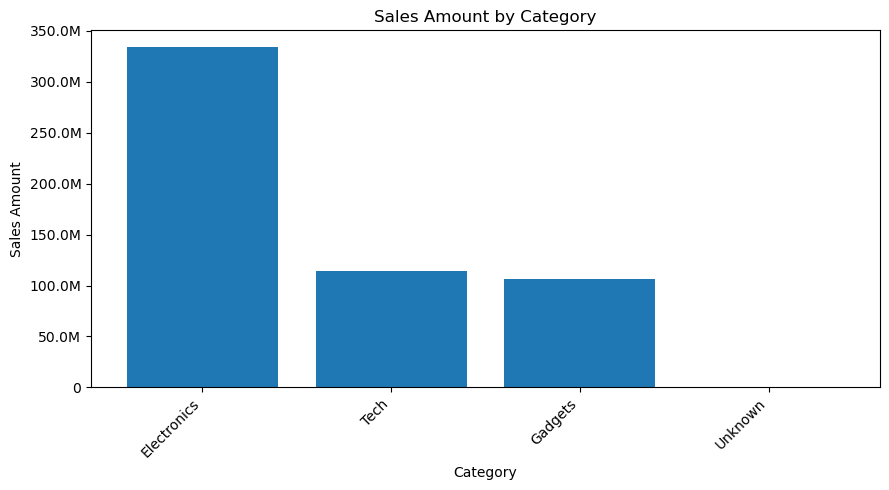

In [11]:
# Calculate total sales by category
sales_by_category = df_clean.groupby("Category")["SalesAmount"].sum().sort_values(ascending=False)

# Create bar chart
plt.figure(figsize=(9, 5))
plt.bar(sales_by_category.index, sales_by_category.values)
plt.title("Sales Amount by Category")
plt.xlabel("Category")
plt.ylabel("Sales Amount")
plt.gca().yaxis.set_major_formatter(currency_formatter)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 12. Visualization: Top products by sales amount

This horizontal bar chart identifies the highest revenue-generating products.

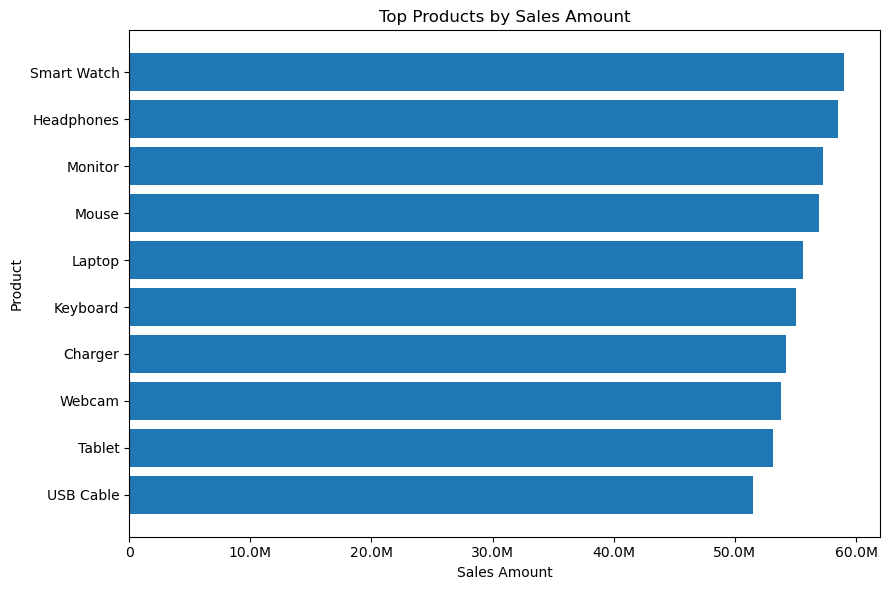

In [12]:
# Calculate top products by sales amount
top_products_by_sales = df_clean.groupby("Product")["SalesAmount"].sum().sort_values(ascending=True).tail(10)

# Create horizontal bar chart
plt.figure(figsize=(9, 6))
plt.barh(top_products_by_sales.index, top_products_by_sales.values)
plt.title("Top Products by Sales Amount")
plt.xlabel("Sales Amount")
plt.ylabel("Product")
plt.gca().xaxis.set_major_formatter(currency_formatter)
plt.tight_layout()
plt.show()

## 13. Visualization: Monthly sales trend

This line chart shows how sales amount changes over time.

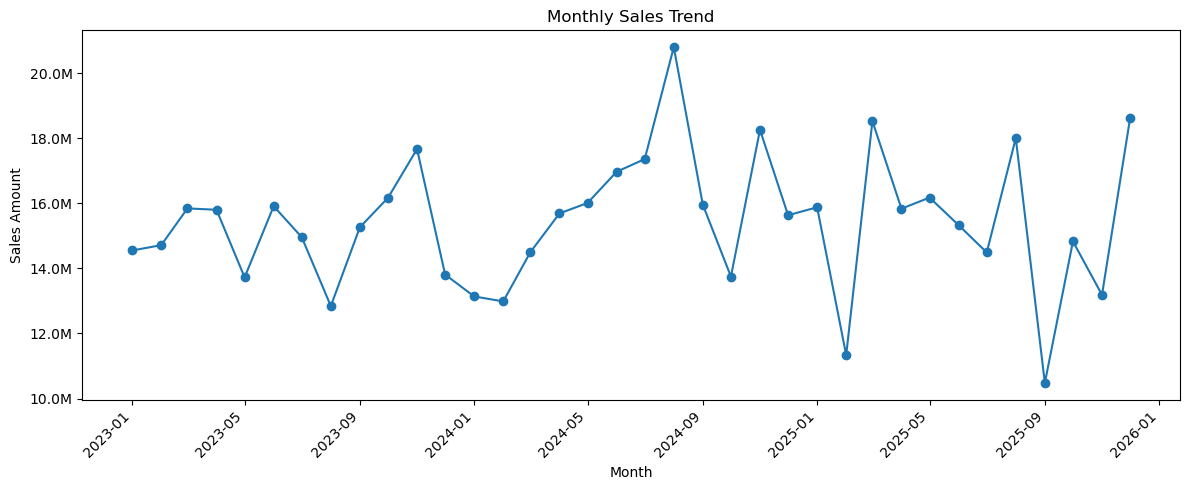

In [13]:
# Calculate monthly sales amount
monthly_sales = df_clean.groupby("OrderMonth")["SalesAmount"].sum().sort_index()

# Create line chart
plt.figure(figsize=(12, 5))
plt.plot(monthly_sales.index, monthly_sales.values, marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales Amount")
plt.gca().yaxis.set_major_formatter(currency_formatter)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 14. Visualization: Order status distribution

This bar chart shows how many orders are delivered, returned, cancelled, shipped, or pending.

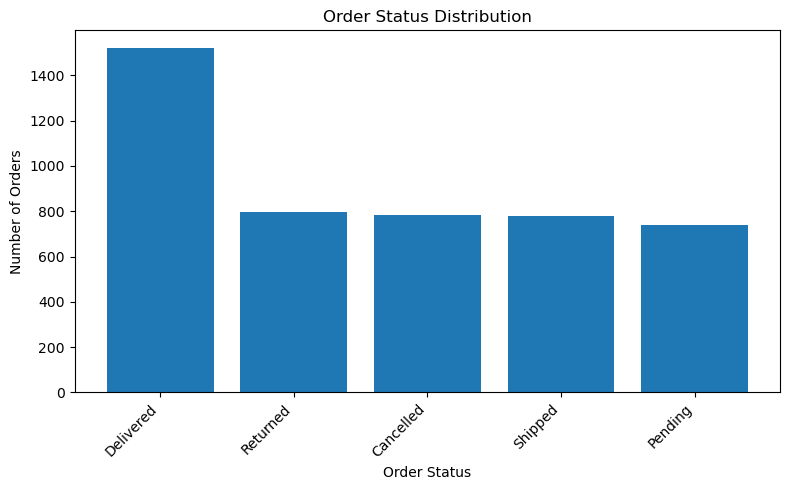

In [14]:
# Count orders by status
order_status_counts = df_clean["OrderStatus"].value_counts()

# Create bar chart
plt.figure(figsize=(8, 5))
plt.bar(order_status_counts.index, order_status_counts.values)
plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 15. Visualization: Payment method distribution

This bar chart shows the number of orders handled by each payment method.

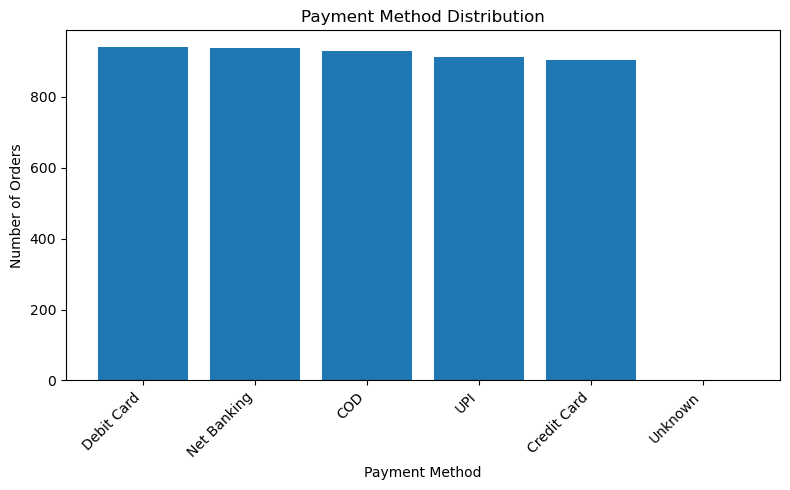

In [15]:
# Count orders by payment method
payment_method_counts = df_clean["PaymentMethod"].value_counts()

# Create bar chart
plt.figure(figsize=(8, 5))
plt.bar(payment_method_counts.index, payment_method_counts.values)
plt.title("Payment Method Distribution")
plt.xlabel("Payment Method")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 16. Visualization: City-wise sales amount

This chart compares total sales amount by city.

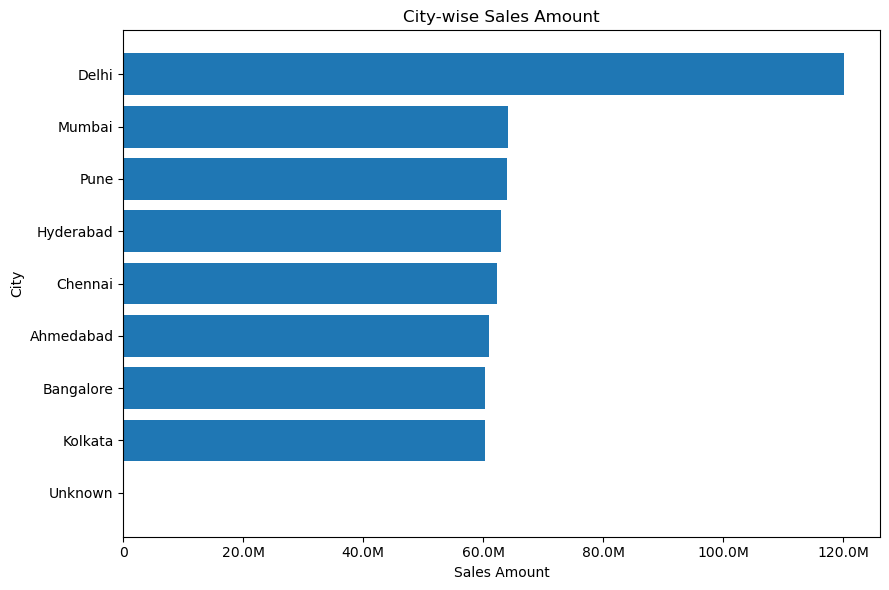

In [16]:
# Calculate sales by city
city_sales = df_clean.groupby("City")["SalesAmount"].sum().sort_values(ascending=True)

# Create horizontal bar chart
plt.figure(figsize=(9, 6))
plt.barh(city_sales.index, city_sales.values)
plt.title("City-wise Sales Amount")
plt.xlabel("Sales Amount")
plt.ylabel("City")
plt.gca().xaxis.set_major_formatter(currency_formatter)
plt.tight_layout()
plt.show()

## 17. Visualization: Price distribution

This histogram shows the distribution of product prices.

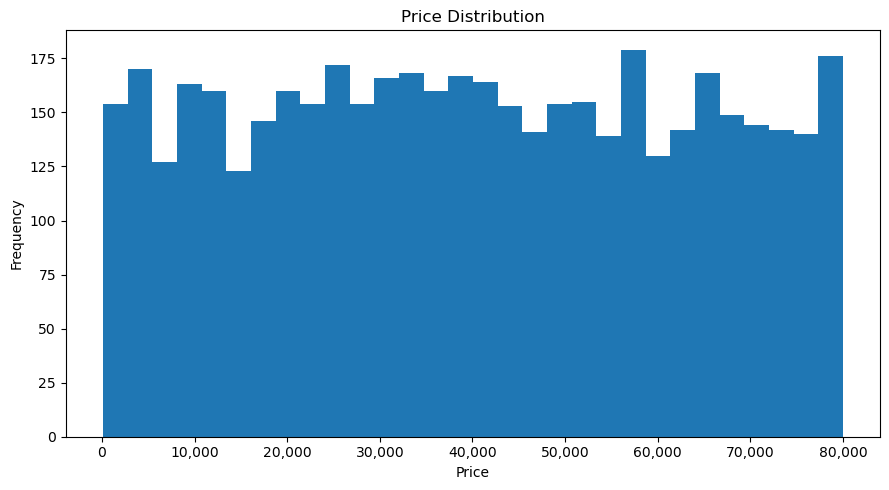

In [17]:
# Create histogram for price distribution
plt.figure(figsize=(9, 5))
plt.hist(df_clean["Price"].dropna(), bins=30)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.gca().xaxis.set_major_formatter(currency_formatter)
plt.tight_layout()
plt.show()

## 18. Visualization: Quantity distribution

This chart shows how frequently each order quantity appears.

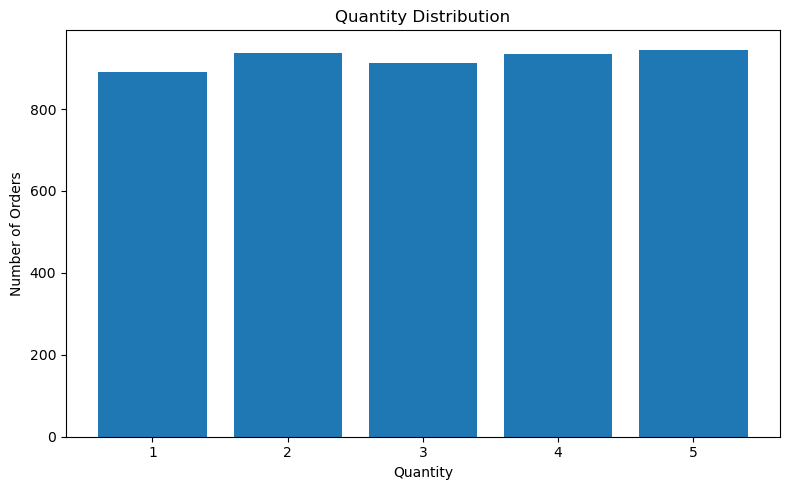

In [18]:
# Count frequency of each quantity value
quantity_counts = df_clean["Quantity"].value_counts().sort_index()

# Create bar chart for quantity distribution
plt.figure(figsize=(8, 5))
plt.bar(quantity_counts.index.astype(str), quantity_counts.values)
plt.title("Quantity Distribution")
plt.xlabel("Quantity")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()

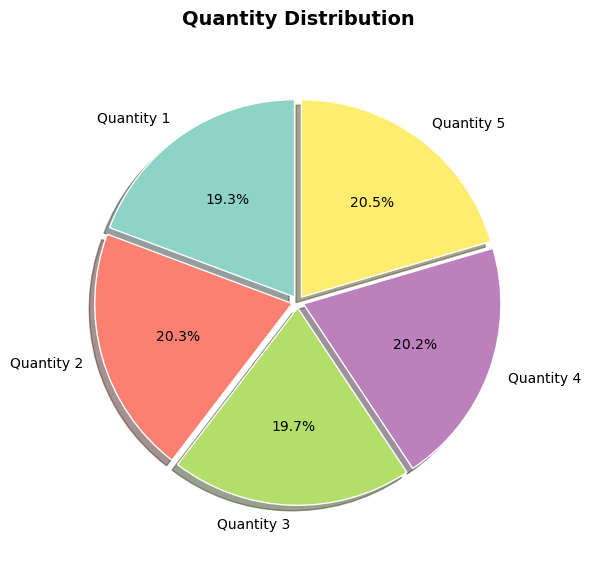

In [23]:
# Count frequency of each quantity value
# Example: how many orders have Quantity = 1, Quantity = 2, etc.
quantity_counts = df_clean["Quantity"].value_counts().sort_index()

# Create labels for each pie slice
# Example labels: Quantity 1, Quantity 2, Quantity 3, etc.
labels = [f"Quantity {qty}" for qty in quantity_counts.index]

# Get the count values for each quantity
sizes = quantity_counts.values

# Generate a colorful palette based on the number of quantity categories
colors = plt.cm.Set3(np.linspace(0, 1, len(quantity_counts)))

# Slightly separate each slice for better visibility
explode = [0.03] * len(quantity_counts)

# Create the pie chart figure
plt.figure(figsize=(6, 6))

# Generate the pie chart
wedges, texts, autotexts = plt.pie(
    sizes,
    labels=labels,
    autopct="%1.1f%%",        # Show percentage values
    startangle=90,            # Start the first slice from the top
    colors=colors,            # Apply colorful palette
    explode=explode,          # Slightly separate slices
    shadow=True,              # Add shadow effect
    wedgeprops={
        "edgecolor": "white",
        "linewidth": 1
    }
)

# Add chart title
plt.title("Quantity Distribution", fontsize=14, fontweight="bold")

# Make sure pie chart is circular
plt.axis("equal")

# Improve layout spacing
plt.tight_layout()

# Display the chart
plt.show()

## 19. Visualization: Correlation among numeric columns

This heatmap shows relationships among numeric variables such as price, quantity, and sales amount.

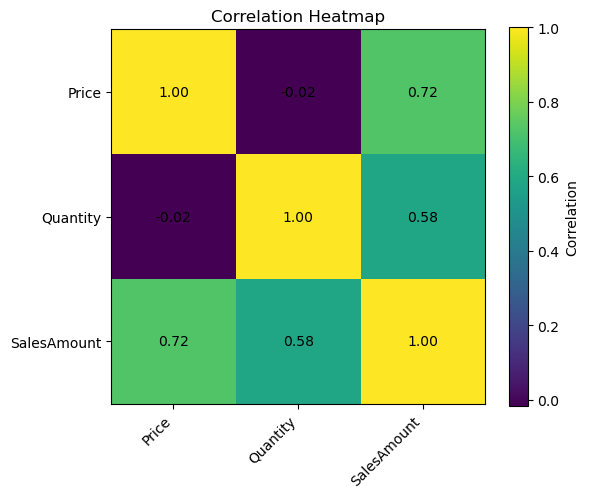

In [19]:
# Select numeric columns for correlation analysis
numeric_columns = [column for column in ["Price", "Quantity", "SalesAmount"] if column in df_clean.columns]
correlation_matrix = df_clean[numeric_columns].corr()

# Create heatmap using matplotlib
plt.figure(figsize=(6, 5))
plt.imshow(correlation_matrix)
plt.title("Correlation Heatmap")
plt.colorbar(label="Correlation")

# Add axis labels
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=45, ha="right")
plt.yticks(range(len(correlation_matrix.index)), correlation_matrix.index)

# Write correlation values inside the cells
for row_index in range(len(correlation_matrix.index)):
    for column_index in range(len(correlation_matrix.columns)):
        plt.text(
            column_index,
            row_index,
            f"{correlation_matrix.iloc[row_index, column_index]:.2f}",
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

## 20. Save the cleaned data for later use

This optional section exports the cleaned DataFrame to a CSV file. You can skip this cell if you only want to perform analysis inside the notebook.

In [20]:
# Save cleaned data as a CSV file
# This creates a reusable cleaned dataset in the same folder as the notebook.
cleaned_output_file = "Ecommerce_Sales_Cleaned.csv"
df_clean.to_csv(cleaned_output_file, index=False)

print(f"Cleaned dataset saved as: {cleaned_output_file}")

Cleaned dataset saved as: Ecommerce_Sales_Cleaned.csv


## 21. Final notes

The notebook has completed the requested workflow:

1. Read the `.xlsx` file into a pandas DataFrame.
2. Generated data summaries.
3. Performed practical data cleaning.
4. Created multiple exploratory visualizations.

You can extend the notebook further by adding customer segmentation, product performance ranking, returned-order analysis, or monthly forecasting.